# Bitcoin Price Exploration

This notebook will look at the bitcoin price from two different periods; 2016-2020 and 2021-2025 which will be used for backtesting purposes later on in other notebooks.

Towards the end of the notebook, additional features will be calculated, such as `returns` (percentage change from prior day) and `log_returns` (logarithm of returns for easy addition).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.graph_objs import candlestick
import yfinance as yf
import talib
from utils.read_prices import read_parquet
from utils.metrics import Metrics

In [2]:
## from January 2016 - December 2020

btc_2016_2020_prices = yf.download(tickers='BTC-USD',
                     start='2016-01-01',
                     end='2020-12-31',
                     auto_adjust=True,
                     multi_level_index=False)

btc_2016_2020_prices.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600


In [3]:
## from january 2021 - december 2025

## for backtesting purposes

btc_2021_2025_prices = yf.download(tickers='BTC-USD',
                     start='2021-01-01',
                     end='2025-12-31',
                     auto_adjust=True,
                     multi_level_index=False)

btc_2021_2025_prices.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782


In [4]:
btc_2016_2020_prices.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [5]:
btc_2016_2020_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2016-01-01 to 2020-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1826 non-null   float64
 1   High    1826 non-null   float64
 2   Low     1826 non-null   float64
 3   Open    1826 non-null   float64
 4   Volume  1826 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.6 KB


In [6]:
btc_2016_2020_prices.describe()

,Close,High,Low,Open,Volume
count,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03
mean,6118.848393,6259.301537,5945.559781,6103.383477,1.164336e+10
std,4703.295017,4820.207635,4535.488914,4674.882347,1.376704e+10
min,364.330994,374.950012,354.914001,365.072998,2.851400e+07
25%,1187.825043,1206.202515,1172.047485,1184.262512,3.338000e+08
50%,6413.792480,6534.830078,6314.354980,6412.694824,5.302091e+09
75%,9208.396973,9360.110352,9035.487061,9209.826904,1.898423e+10
max,28840.953125,28937.740234,27360.089844,27360.089844,7.415677e+10


In [7]:
btc_2021_2025_prices.describe()

,Close,High,Low,Open,Volume
count,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03
mean,54408.228931,55440.815712,53249.015332,54377.884361,3.717743e+10
std,29461.698618,29865.535897,29021.845342,29456.676425,2.305696e+10
min,15787.284180,16253.047852,15599.046875,15782.300781,5.331173e+09
25%,29397.714844,29952.029297,28975.560547,29376.455078,2.133027e+10
50%,46453.566406,47510.726562,45235.816406,46415.898438,3.180847e+10
75%,69122.335938,70046.273438,67535.132812,69020.546875,4.721185e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


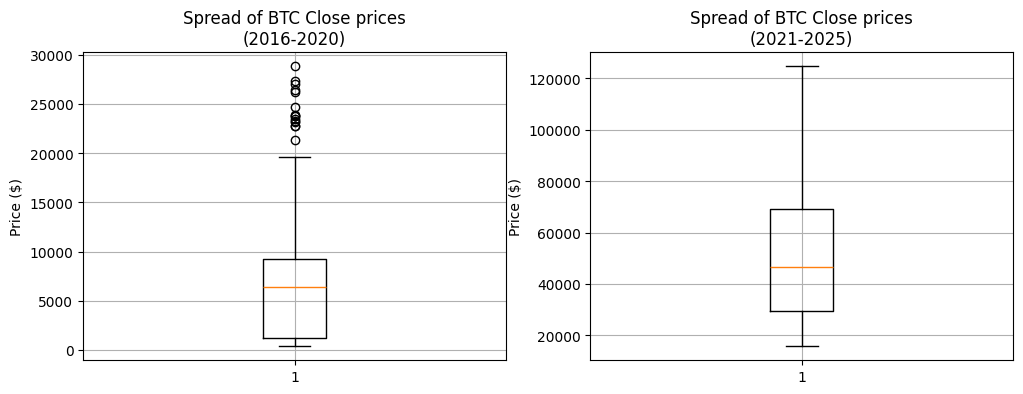

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].boxplot(btc_2016_2020_prices["Close"])
ax[0].set_title("Spread of BTC Close prices\n(2016-2020)")
ax[0].set_ylabel("Price ($)")
ax[0].set_xlabel('')
ax[0].grid(.4)

ax[1].boxplot(btc_2021_2025_prices["Close"])
ax[1].set_title("Spread of BTC Close prices\n(2021-2025)")
ax[1].set_ylabel("Price ($)")
ax[1].set_xlabel('')
ax[1].grid(.4)

plt.show()

In [10]:
btc_2016_2020_prices[btc_2016_2020_prices["Close"] > 20000].shape[0] ## how many days the price closed above the whisker in the plot above

15

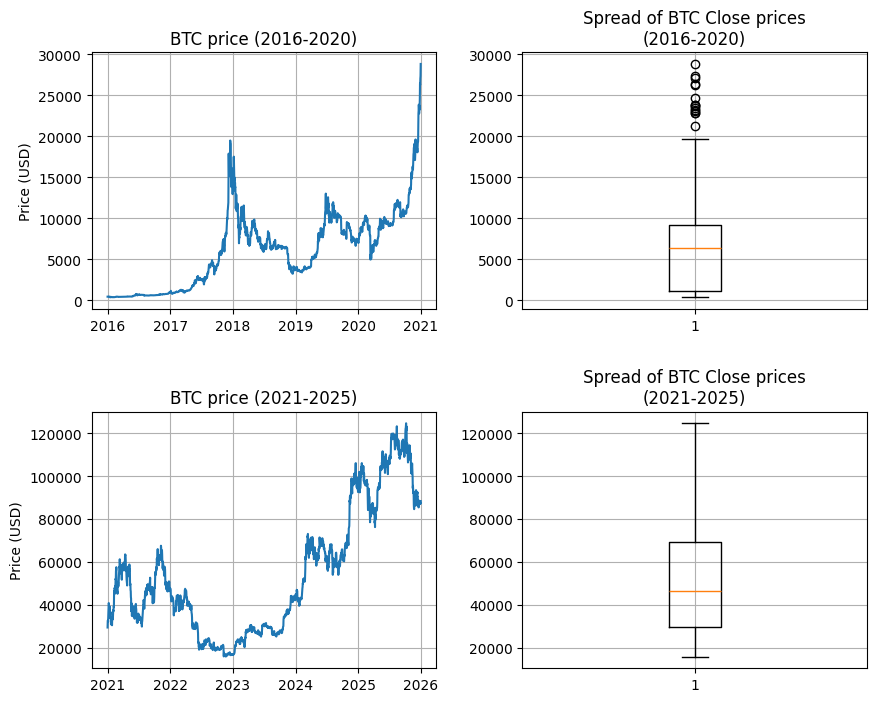

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(10,8), gridspec_kw={'hspace': 0.40, 'wspace': 0.25})

ax[0,0].plot(btc_2016_2020_prices["Close"])
ax[0,0].set_title("BTC price (2016-2020)")
ax[0,0].set_ylabel("Price (USD)")
ax[0,0].grid(.4)

ax[0,1].boxplot(btc_2016_2020_prices["Close"])
ax[0,1].set_title("Spread of BTC Close prices\n(2016-2020)")
ax[0,1].set_xlabel('')
ax[0,1].grid(.4)

ax[1,0].plot(btc_2021_2025_prices["Close"])
ax[1,0].set_title("BTC price (2021-2025)")
ax[1,0].set_ylabel("Price (USD)")
ax[1,0].grid(.4)

ax[1,1].boxplot(btc_2021_2025_prices["Close"])
ax[1,1].set_title("Spread of BTC Close prices\n(2021-2025)")
ax[1,1].set_xlabel('')
ax[1,1].grid(.4)

plt.show()

## US Interest Rates

Using data from the Federal Reserve Bank of St. Louis we will add the interest rate as another feature to the bitcoin prices to see if there are any interesting price movements/strategy movements when factoring in the interest rate.

In [12]:
fred_df = read_parquet('../price_ranges/federal_funds_rate_ammended.parquet')
fred_df.head()

,DFF
observation_date,
2016-01-01,0.20
2016-01-02,0.20
2016-01-03,0.20
2016-01-04,0.36
2016-01-05,0.36


In [13]:
fred_2016_2020 = fred_df.loc['2016-01-01':'2020-12-31']
fred_2021_2025 = fred_df.loc['2021-01-01':'2025-12-31'] ## use for backtest dataset
fred_2016_2020

,DFF
observation_date,
2016-01-01,0.20
2016-01-02,0.20
2016-01-03,0.20
2016-01-04,0.36
2016-01-05,0.36
...,...
2020-12-27,0.09
2020-12-28,0.09
2020-12-29,0.09


In [14]:
btc_2016_2020_prices['interest_rate'] = fred_2016_2020['DFF'].values[:-1]
btc_2021_2025_prices['interest_rate'] = fred_2021_2025['DFF'].values[:-1]


In [15]:
btc_2016_2020_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2016-01-01 to 2020-12-30
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          1826 non-null   float64
 1   High           1826 non-null   float64
 2   Low            1826 non-null   float64
 3   Open           1826 non-null   float64
 4   Volume         1826 non-null   int64  
 5   interest_rate  1826 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 99.9 KB


In [16]:
btc_2021_2025_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1825 entries, 2021-01-01 to 2025-12-30
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close          1825 non-null   float64
 1   High           1825 non-null   float64
 2   Low            1825 non-null   float64
 3   Open           1825 non-null   float64
 4   Volume         1825 non-null   int64  
 5   interest_rate  1825 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 99.8 KB


In [17]:
btc_2016_2020_prices.to_parquet('../price_ranges/btc_price_2016-2020.parquet')
btc_2021_2025_prices.to_parquet('../price_ranges/btc_price_2021-2025.parquet')

In [18]:
fig = make_subplots(1,1)

fig.add_trace(
    go.Scatter(x=btc_2016_2020_prices.index, y=btc_2016_2020_prices['Close'],
            name='Close Price'),
            row=1,
            col=1
            )

fig.show()

We can see that the price of bitcoin over the last 5 years has seen many fluctuations. Because of the volatility there is opportunity in capitalizing on these massive price swings. But also the possibility for massive losses.

Bitcoin is what traders would call a high risk - high reward type of asset.

### Returns

Since we are looking at daily price movement our period will be 365 (prior period will be yesterday). If we were looking at monthly price data, the period would be 12 (prior period would be the month prior). And so on and so on.

The daily differences in prices from the day prior can be expressed like so:

In [ ]:
# returns = df.iloc[:, :-1].pct_change().dropna(axis=0) + 1

## adding the 1 at the end makes it the multiplier
## without the 1 the pct_change() method returns the percent change from prior period
returns = btc_2016_2020_prices['Close'].pct_change() + 1

returns.head(10)

Date
2016-01-01         NaN
2016-01-02    0.997937
2016-01-03    0.992093
2016-01-04    1.007163
2016-01-05    0.997389
2016-01-06    0.993391
2016-01-07    1.067450
2016-01-08    0.989481
2016-01-09    0.987602
2016-01-10    1.000849
Name: Close, dtype: float64

### Why Use Logarithmic Returns

* additive - logarithms can be added/subtracted
* normality - log returns tend to have properties closer to normality which makes them better fit for financial models
* continuously compounded

In [20]:
btc_2016_2020_prices['returns'] = btc_2016_2020_prices['Close'].pct_change() + 1
btc_2016_2020_prices['log_returns'] = np.log(btc_2016_2020_prices['returns'])

btc_2021_2025_prices["returns"] = btc_2021_2025_prices["Close"].pct_change() + 1
btc_2021_2025_prices["log_returns"] = np.log(btc_2021_2025_prices["returns"])

In [21]:
btc_2016_2020_prices["returns"].describe()

count    1825.000000
mean        1.003077
std         0.039170
min         0.628305
25%         0.988796
50%         1.002180
75%         1.017551
max         1.252472
Name: returns, dtype: float64

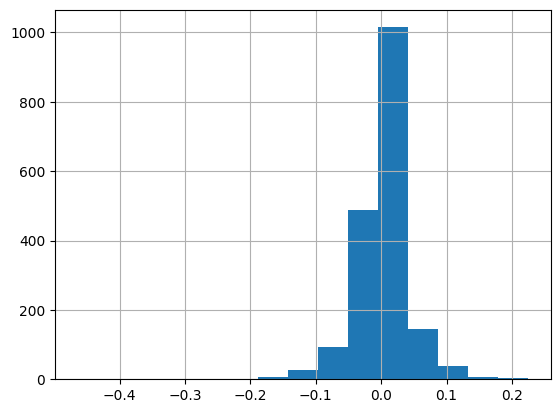

In [29]:
btc_2016_2020_prices["log_returns"].hist(bins=15)
plt.grid(.4)
plt.show()

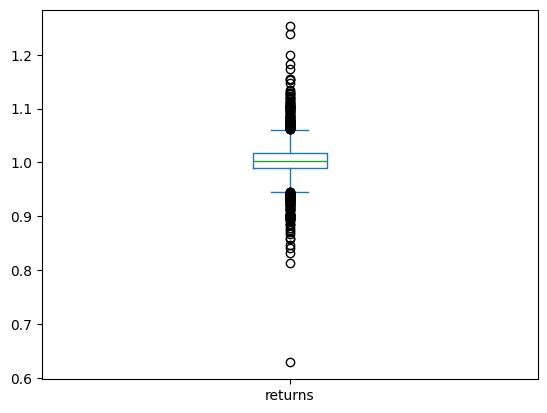

In [22]:
btc_2016_2020_prices["returns"].plot(kind="box")
plt.show()

In [23]:
btc_2021_2025_prices["returns"].describe()

count    1824.000000
mean        1.001072
std         0.030601
min         0.840253
25%         0.986817
50%         0.999992
75%         1.014917
max         1.187465
Name: returns, dtype: float64

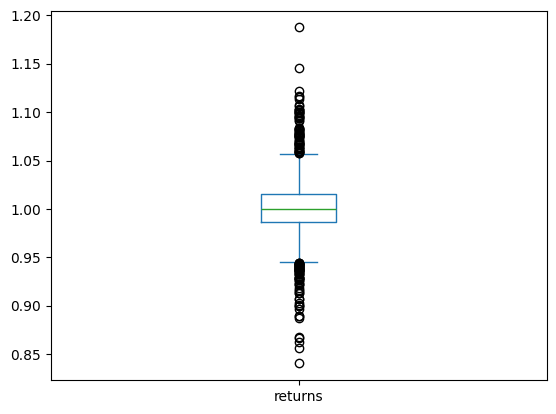

In [24]:
btc_2021_2025_prices["returns"].plot(kind="box")
plt.show()

In [25]:
btc_2016_2020_prices.to_parquet('../price_ranges/btc_price_2016-2020.parquet')
btc_2021_2025_prices.to_parquet("../price_ranges/btc_price_2021-2025.parquet")

## Mean Reversion Strategy

In [ ]:
btc_2016_2020_prices

,Close,High,Low,Open,Volume,interest_rate,EWM_0.1,EWM_0.5
Date,,,,,,,,
2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.09,29374.152344,29374.152344
2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.09,29649.463867,30750.709961
2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,0.09,29962.719824,31766.366699
2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.09,30163.639248,31869.140381
2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.09,30546.518292,32930.785034
...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,3.64,88497.655911,87395.516518
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,3.64,88428.105945,87598.836384
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,3.64,88368.878944,87717.336161


In [ ]:
df_3 = btc_2016_2020_prices[['Close', 'log_returns', 'interest_rate']].copy()

In [ ]:
df_3['SMA'] = df_3['Close'].rolling(25).mean()
df_3['Distance'] = df_3['Close'] - df_3['SMA']

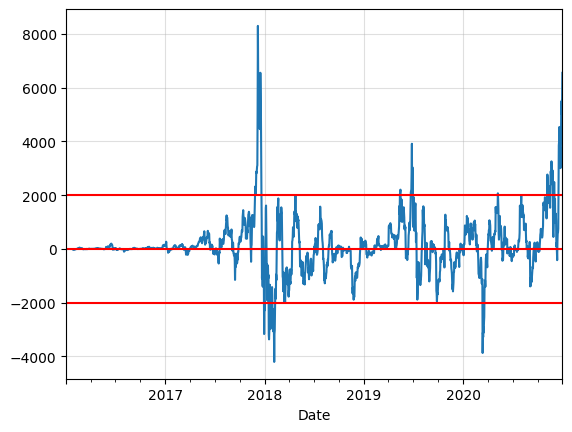

In [ ]:
df_3['Distance'].plot(kind='line')
plt.axhline(0, color='r')
plt.axhline(2000, color='r')
plt.axhline(-2000, color='r')
plt.grid(alpha=.4)
plt.show()

In [ ]:
SMA = 25
thresholds = np.linspace(1500, 2500, 5)
# thresholds = 2000
threshold_strategies = [df_3['log_returns']]

for i in thresholds:
    df = df_3.copy()

    df['SMA'] = df['Close'].rolling(SMA).mean()
    df['distance'] = df['Close'] - df['SMA']
    df.dropna()

    ## strategy of buying/selling given the threshold
    df['position'] = np.where(df['distance'] > i, -1, np.nan)

    df['position'] = np.where(df['distance'] < -i,
                                1, df['position'])

    df['position'] = np.where(df['distance'] * df['distance'].shift(1) < 0, 0, df['position'])

    df['position'] = df['position'].ffill().fillna(0)

    strategy = df['position'].shift(1) * df['log_returns']
    strategy = strategy.dropna()

    threshold_strategies.append(strategy)

In [ ]:
thresholds = thresholds.tolist()

In [ ]:
thresholds.append(0)

In [ ]:
thresholds.sort()

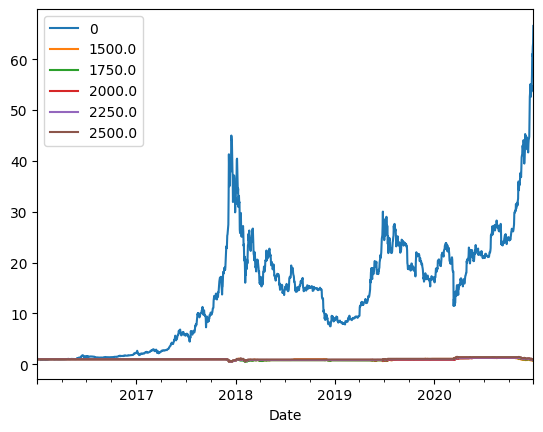

In [ ]:
for (strategy,
    threshold,
    # linestyle
    ) \
        in zip(
    threshold_strategies,
    thresholds, 
    # ['-', '--', '--', '--', '--', '--', '--']
    ):
    np.exp(strategy.cumsum()).plot(kind='line',
                                   label=f"{threshold}",
                                #    linestyle=linestyle
                                   )

plt.legend()
plt.show()

### Technical Indicators

The TA-Lib library provides many different indicators. We will look at a few of them to add to our price dataset.

In [ ]:
btc_2016_2020_prices['roc'] = talib.ROC(btc_2016_2020_prices['Close'])
btc_2016_2020_prices['atr'] = talib.ATR(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])
btc_2016_2020_prices['di+'] = talib.PLUS_DI(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])
btc_2016_2020_prices['di-'] = talib.MINUS_DI(btc_2016_2020_prices['High'], btc_2016_2020_prices['Low'], btc_2016_2020_prices['Close'])

In [ ]:
btc_2016_2020_prices.head()

In [ ]:
btc_2016_2020_prices[['roc']].plot(kind='line')
plt.title("ROC Indicator")
plt.grid(.4)
plt.show()

### July 2021 - December 2022

In [ ]:
july_2021_december_2022_df = btc_2021_2025_prices.loc['2021-07-01': '2022-12-31']

KeyError: 'log_returns'

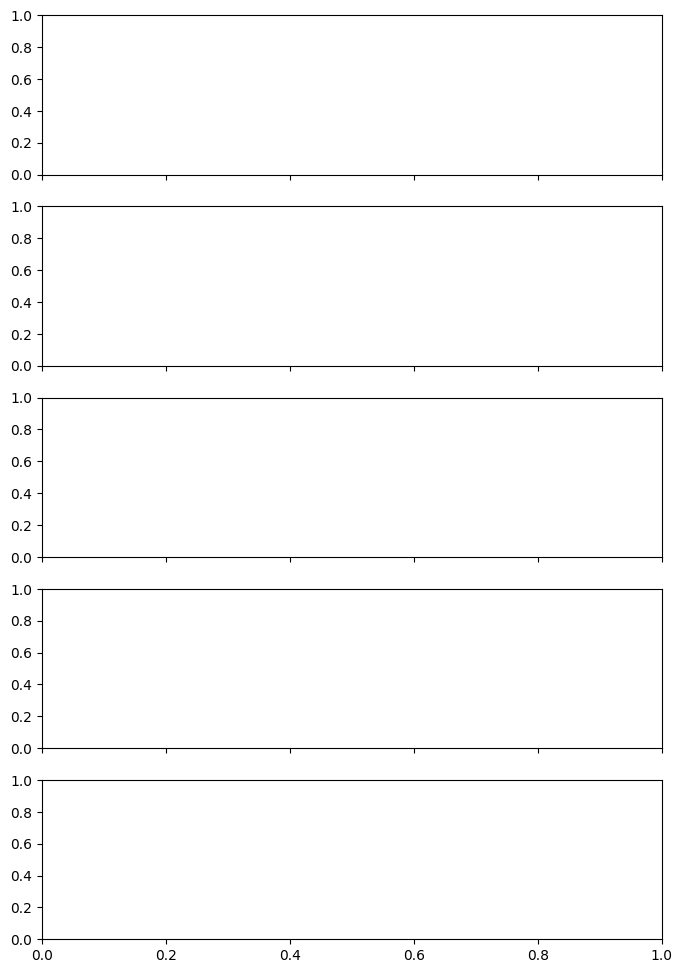

In [ ]:
fig, ax = plt.subplots(5, 1, sharex=True, figsize=(8,12))

macd_line, signal_line, macd_hist = talib.MACD(july_2021_december_2022_df['Close'])

# adx_line = talib.ADX(july_2021_december_2022_df['High'], july_2021_december_2022_df['Low'], july_2021_december_2022_df['Close'])

############
ax[0].plot(np.exp(july_2021_december_2022_df['log_returns']).cumprod(), label='Buy-n-Hold')
ax[0].plot(np.exp(july_2021_december_2022_df['log_return_trend_follow']).cumprod(), label='Trend-Follow')
ax[0].grid(alpha=.3)
ax[0].set_ylabel('Price Multiplier per Strategy')
ax[0].set_title('Cumulative return of different trading strategies')
ax[0].legend()

############
ax[1].plot(july_2021_december_2022_df['interest_rate'], label='US Interest Rate')
ax[1].grid(alpha=.3)
ax[1].set_ylabel('Percent')
ax[1].set_title('US Interest Rate')
ax[1].legend()

############
ax[2].plot(july_2021_december_2022_df['Close'], label='Close Price')
ax[2].plot(july_2021_december_2022_df['SMA-50'], label='50 day moving average')
ax[2].plot(july_2021_december_2022_df['SMA-200'], label='200-day moving average')
ax[2].grid(alpha=.3)
ax[2].set_ylabel('Price')
ax[2].set_title('Close price with moving averages')
ax[2].legend()

###########
ax[3].plot(macd_line, label='MACD Line')
ax[3].plot(signal_line, label='Signal')
ax[3].bar(july_2021_december_2022_df.index, macd_hist)
ax[3].set_title('MACD')
ax[3].grid(alpha=.3)
ax[3].legend()

############
ax[4].plot(talib.RSI(july_2021_december_2022_df['Close']), label='RSI')
ax[4].set_title('RSI')
ax[4].grid(alpha=.3)
ax[4].legend()

############
# ax[5].plot(adx_line, label='ADX')
# ax[5].set_title('ADX')
# ax[5].grid(alpha=.3)
# ax[5].legend()

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

In [ ]:
atr = talib.ATR(btc_df['High'], btc_df['Low'], btc_df['Close'])

In [ ]:
atr.plot(kind='line')
plt.grid(alpha=.3)
plt.show()